In [1]:
import pandas as pd

file_path = 'df_prop.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,2590661,1214.0,2,26,11903,0,2,1,1,2,...,0.0,0.00,0.0,0,0,1.000000,0.5,0.500000,0.0,2
1,1902592,181.0,2,24,11106,0,2,1,1,2,...,0.0,0.00,0.0,0,0,0.000000,0.0,0.000000,0.0,0
2,6077257,171.0,2,35,12803,0,3,1,1,1,...,0.0,0.00,0.0,0,0,0.333333,0.0,0.666667,0.0,0
3,4635462,497.0,2,31,29806,0,1,1,1,1,...,0.0,0.00,0.0,0,0,0.000000,0.0,0.000000,0.5,1
4,6733361,1684.0,2,35,43402,0,4,1,1,1,...,0.5,0.25,0.5,0,0,0.000000,0.0,0.000000,0.0,2


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 51 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 6   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 7   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 8   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 9   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 11  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 12  CO_MATERIAL_PISO_FAM         

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [6]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [7]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS'

## Análise de correlação das variáveis

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

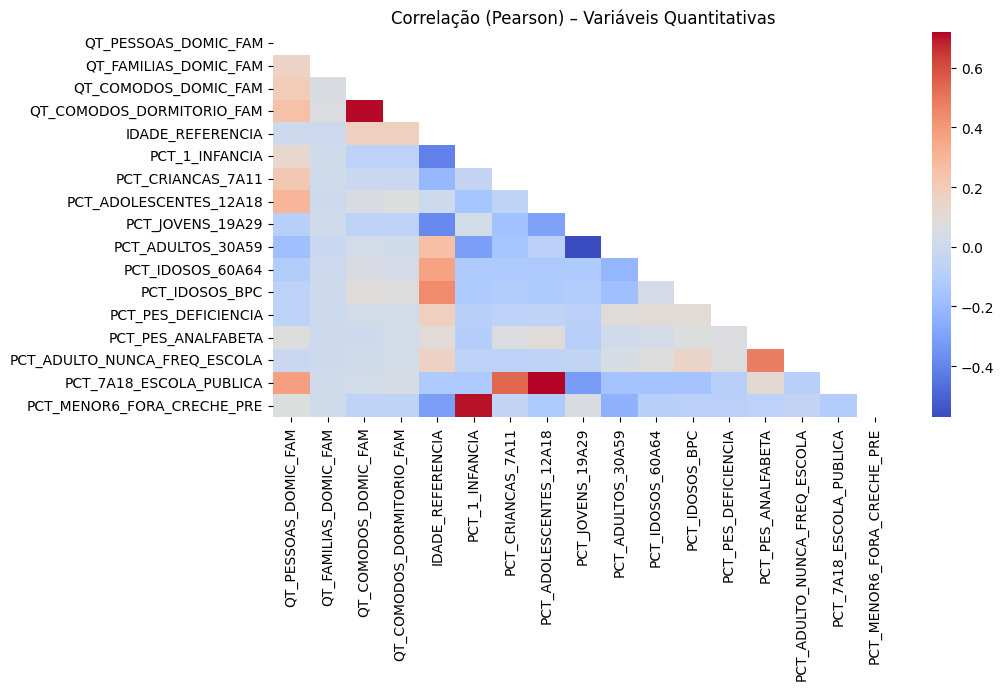

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [10]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.719912
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.713343
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.701578
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.565910
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.541806
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.483069
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.443460
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.405600
61,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.380080
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.376866


In [11]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [12]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


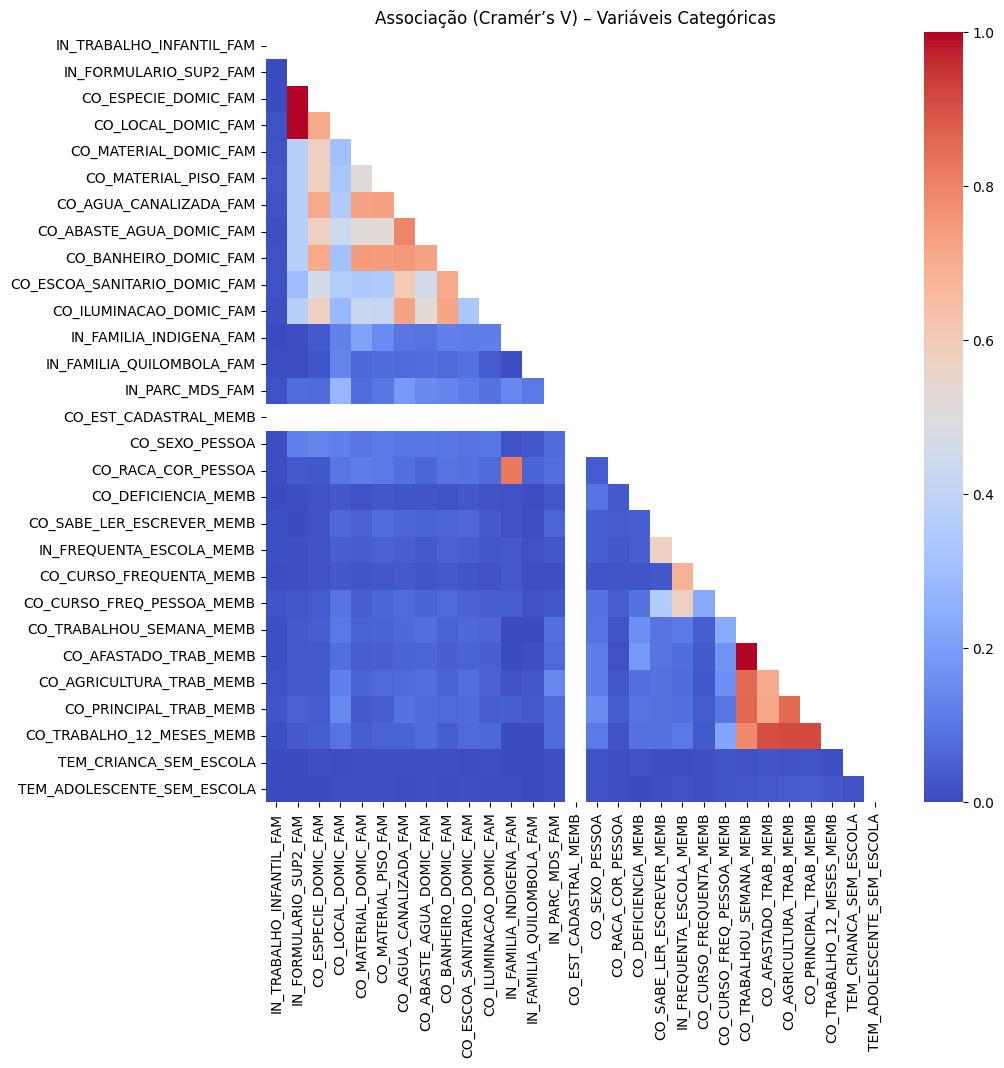

In [13]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [14]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999895
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999895
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.915754
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.910428
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.909107
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.862000
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.859112
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.859021
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.826105


In [15]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999895
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999895
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.915754
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.910428
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.909107
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.862000
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.859112
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.859021
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.826105


In [16]:
df = df.drop(columns=['CO_TRABALHOU_SEMANA_MEMB','IN_FORMULARIO_SUP2_FAM', 'CO_PRINCIPAL_TRAB_MEMB','CO_AGRICULTURA_TRAB_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM'])

In [17]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
       'PCT_IDOSOS_BPC', 'PCT_PES_DEFIC

In [18]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,2590661,2,26,11903,2,1,1,2,4,1,...,0.0,0.00,0.0,0,0,1.000000,0.5,0.500000,0.0,2
1,1902592,2,24,11106,2,1,1,2,4,1,...,0.0,0.00,0.0,0,0,0.000000,0.0,0.000000,0.0,0
2,6077257,2,35,12803,3,1,1,1,3,1,...,0.0,0.00,0.0,0,0,0.333333,0.0,0.666667,0.0,0
3,4635462,2,31,29806,1,1,1,1,5,2,...,0.0,0.00,0.0,0,0,0.000000,0.0,0.000000,0.5,1
4,6733361,2,35,43402,4,1,1,1,7,2,...,0.5,0.25,0.5,0,0,0.000000,0.0,0.000000,0.0,2


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 45 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM       

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [20]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
       'PCT_IDOSOS_BPC', 'PCT_PES_DEFIC

In [21]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [22]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_TRABALHO_12_MESES_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB']


In [23]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [24]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [25]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [26]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [27]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [28]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [29]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [31]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29'...
                                 ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
                                  'CO_MATERIAL_DOMIC_FAM',
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'IN_FREQUENTA_ESCOLA_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [32]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,pct__PCT_ADULTOS_30A59,...,multicat__CO_CURSO_FREQ_PESSOA_MEMB_8,multicat__CO_CURSO_FREQ_PESSOA_MEMB_9,multicat__CO_CURSO_FREQ_PESSOA_MEMB_10,multicat__CO_CURSO_FREQ_PESSOA_MEMB_11,multicat__CO_CURSO_FREQ_PESSOA_MEMB_12,multicat__CO_CURSO_FREQ_PESSOA_MEMB_13,multicat__CO_CURSO_FREQ_PESSOA_MEMB_14,multicat__CO_CURSO_FREQ_PESSOA_MEMB_15,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.037975,0.02,0.072917,0.031915,0.295455,0.00,0.5,0.00,0.0,0.5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15.0,8001.0
1,0.037975,0.02,0.052083,0.021277,0.329545,0.00,0.0,0.50,0.0,0.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,4557.0
2,0.088608,0.02,0.062500,0.042553,0.340909,0.00,0.0,0.00,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,2603.0
3,0.037975,0.02,0.020833,0.021277,0.079545,0.00,0.5,0.00,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,1108.0
4,0.050633,0.02,0.062500,0.031915,0.170455,0.25,0.0,0.25,0.0,0.5,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,8201.0


### Comparando diversos modelos

In [33]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ------------------------------------------------------------
# 1) MODELOS
# ------------------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    ),
}

# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (sem salvar em disco)
# ------------------------------------------------------------
pipes = {}      # pipelines treinados em memória (no notebook)
results = []    # métricas

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)

    # guarda pipeline treinado em memória
    pipes[name] = pipe

    # predições
    y_pred = pipe.predict(X_test).ravel()

    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # precisão e revocação (macro e weighted)
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    # AUC (se existir predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "auc_weighted_ovr": auc,
    })

# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results







Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,accuracy,f1_weighted,f1_macro,precision_macro,recall_macro,precision_weighted,recall_weighted,auc_weighted_ovr
4,XGBoost,0.653480,0.625580,0.525450,0.610464,0.512904,0.636007,0.653480,0.782470
3,HistGradientBoosting,0.652020,0.624461,0.524444,0.607058,0.512054,0.634064,0.652020,0.781274
5,CatBoost,0.650940,0.621622,0.518465,0.610187,0.507404,0.634108,0.650940,0.779535
2,GradientBoosting,0.643250,0.608672,0.494723,0.604273,0.490206,0.626641,0.643250,0.770627
0,RandomForest,0.628835,0.605877,0.505898,0.555933,0.496676,0.605058,0.628835,0.750247
1,LogisticRegression,0.612430,0.565044,0.423633,0.542146,0.443315,0.583813,0.612430,0.727882


### O modelo multiclasse tem performance significativamente inferior ao binário. A acurácia cai de ~75% para ~65%, e o AUC de ~0.83 para ~0.78. Isso é esperado: classificar em 3 classes é um problema mais difícil do que classificar em 2.
### O recall macro de apenas 0.5129 é preocupante. Isso indica que, em média, o modelo acerta pouco mais da metade das famílias em cada classe. Provavelmente o modelo tem dificuldade especialmente com a classe intermediária ("baixa renda"), que tende a ser confundida tanto com "pobreza" quanto com "acima de ½ SM". Esse é um padrão clássico em problemas multiclasse com classes ordinais e fronteiras próximas.
### A precision macro de 0.61 também é inferior à precision do binário (~0.75 no threshold 0.50 e ~0.89 no threshold 0.80). Isso significa mais convocações indevidas se o modelo multiclasse for usado para triagem
### O F1 macro de 0.53 vs. F1 do binário de 0.79 mostra que o modelo multiclasse tem um equilíbrio precision-recall muito pior. A queda é de quase 30 pontos percentuais.
### A granularidade adicional não compensa a perda de performance. Embora separar "pobreza" de "baixa renda" possa ter valor conceitual para a política pública, na prática o modelo não consegue fazer essa distinção de forma confiável o suficiente.